In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Shortest Path:
A -> B -> E -> G
Total Cost: 8


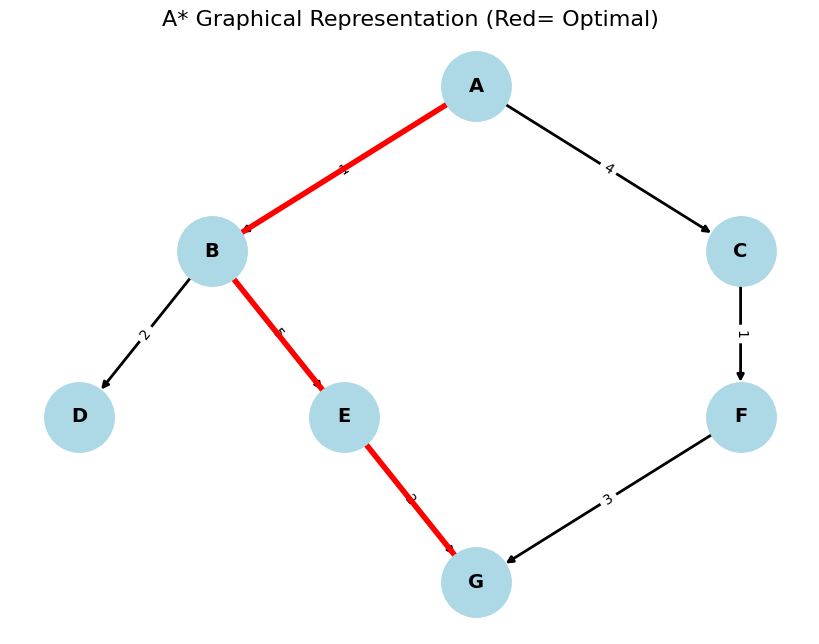

In [26]:
import heapq

graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('G', 2)],
    'F': [('G', 3)],
    'G': []
}

heuristic = {
    'A': 7,
    'B': 6,
    'C': 2,
    'D': 5,
    'E': 2,
    'F': 1,
    'G': 0
}

def astar(graph, heuristic, start, goal):
    pq = [(heuristic[start], 0, start, [start])]
    visited = set()

    while pq:
        f, g, node, path = heapq.heappop(pq)

        if node == goal:
            return path, g

        if node in visited:
            continue

        visited.add(node)

        for neighbor, cost in graph[node]:
            new_g = g + cost
            new_f = new_g + heuristic[neighbor]
            heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return None, float('inf')

path, cost = astar(graph, heuristic, 'A', 'G')
print("Shortest Path:")
print(" -> ".join(path))
print("Total Cost:", cost)


G= nx.DiGraph()

for node in graph:
    for neighbor, weight in graph[node]:
        G.add_edge (node, neighbor, weight=weight)

pos={
    'A':(0,3),
    'B':(-1,2),
    'C':(1,2),
    'D':(-1.5, 1),
    'E':(-0.5,1),
    'F':(1,1),
    'G':(0,0)
}
plt.figure(figsize=(8,6))

nx.draw(
    G,pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    edge_color='black',
    arrows=True,
    width=2

    
  
)

edge_labels=nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)
path_edges=list(zip(path[:-1],path[1:]))

nx.draw_networkx_edges(
    G,pos,
    edgelist=path_edges,
    edge_color='red',
    width=4,
    arrows=True
)

plt.title("A* Graphical Representation (Red= Optimal)",fontsize=16)
plt.axis('off')
plt.show()

Optimal solution path:
A-->C-->F
Total Cost: 6


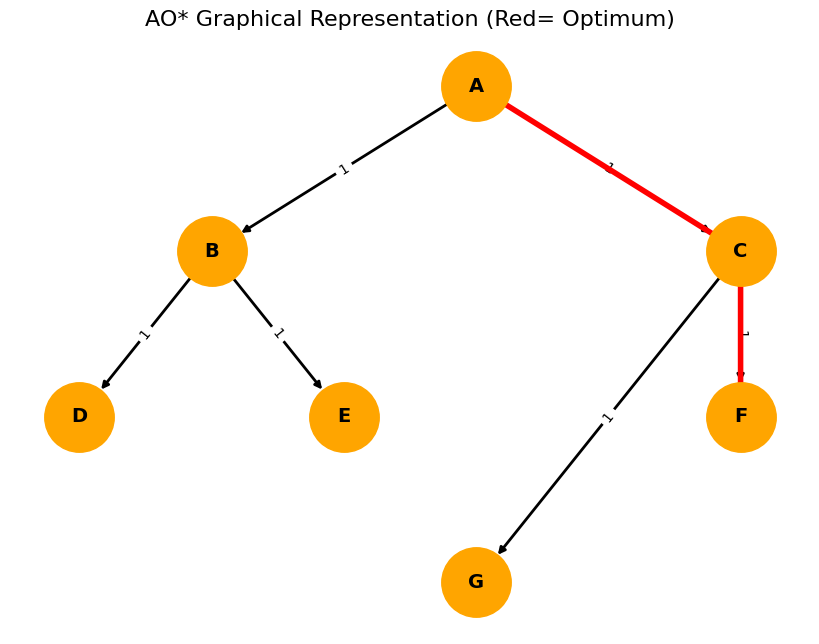

In [37]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    'A': {'type': 'OR', 'children': [('B', 1), ('C', 1)]},
    'B': {'type': 'AND', 'children': [('D', 1), ('E', 1)]},
    'C': {'type': 'OR', 'children': [('F', 1), ('G', 1)]},
    'D': {'type': 'LEAF', 'cost': 2},
    'E': {'type': 'LEAF', 'cost': 3},
    'F': {'type': 'LEAF', 'cost': 4},
    'G': {'type': 'LEAF', 'cost': 6}
}

def ao_star(node):
    info = graph[node]      # Fixed

    if info['type'] == 'LEAF':
        return info['cost'], [node]

    if info['type'] == 'OR':
        best_cost = float('inf')
        best_path = []

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total = edge_cost + child_cost

            if total < best_cost:
                best_cost = total
                best_path = [node] + child_path

        return best_cost, best_path

    if info['type'] == 'AND':
        total_cost = 0
        full_path = [node]

        for child, edge_cost in info['children']:
            child_cost, child_path = ao_star(child)
            total_cost += edge_cost + child_cost
            full_path += child_path

        return total_cost, full_path


cost, path = ao_star('A')

print("Optimal solution path:")
print("-->".join(path))
print("Total Cost:", cost)


G=nx.DiGraph()
for node, info in graph.items():
    if'children' in info:
        for child , weight in info ['children']:
            G.add_edge(node, child, weight=weight)

pos={
    'A':(0,3),
    'B':(-1,2),
    'C':(1,2),
    'D':(-1.5, 1),
    'E':(-0.5,1),
    'F':(1,1),
    'G':(0,0)
    
}
plt.figure(figsize=(8,6))

nx.draw(
    G,pos,
    with_labels=True,
    node_color='orange',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    edge_color='black',
    arrows=True,
    width=2

    
  
)

edge_labels=nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)
path_edges=list(zip(path[:-1],path[1:]))

nx.draw_networkx_edges(
    G,pos,
    edgelist=path_edges,
    edge_color='red',
    width=4,
    arrows=True

)

plt.title("AO* Graphical Representation (Red= Optimum)",fontsize=16)
plt.axis('off')
plt.show()